In [36]:
import matplotlib.pyplot as plt
import matplotlib as mlp
import pandas as pd
import seaborn as sns

from helpers import sql

# pandas formatting
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', 1000)
pd.set_option('display.float_format', '{:.0f}'.format)

# import
documents = sql(
    query="""
          SELECT csas2_document.id, csas2_document.created_at,
              csas2_document.updated_at, dev_link_en, dev_link_fr,
              library_link_en, library_link_fr, sharepoint_archive_en,
              sharepoint_archive_fr, url_en, url_fr, ekme_gcdocs_en,
              ekme_gcdocs_fr, cat_number_en, cat_number_fr, isbn_en, isbn_fr
          FROM csas2_document JOIN csas2_documenttracking
                                   ON csas2_documenttracking.document_id
                                           = csas2_document.id
          """,
    database='dmapps_260313'
)
# convert links to bools (True if inputted)
documents.iloc[:, 3:] = documents.iloc[:, 3:].notnull()

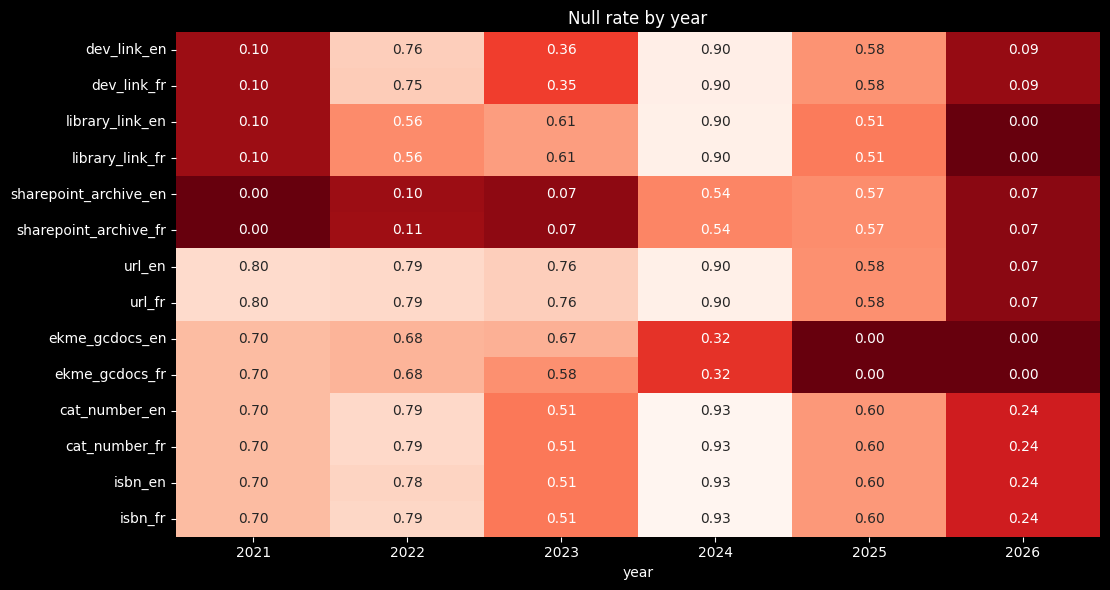

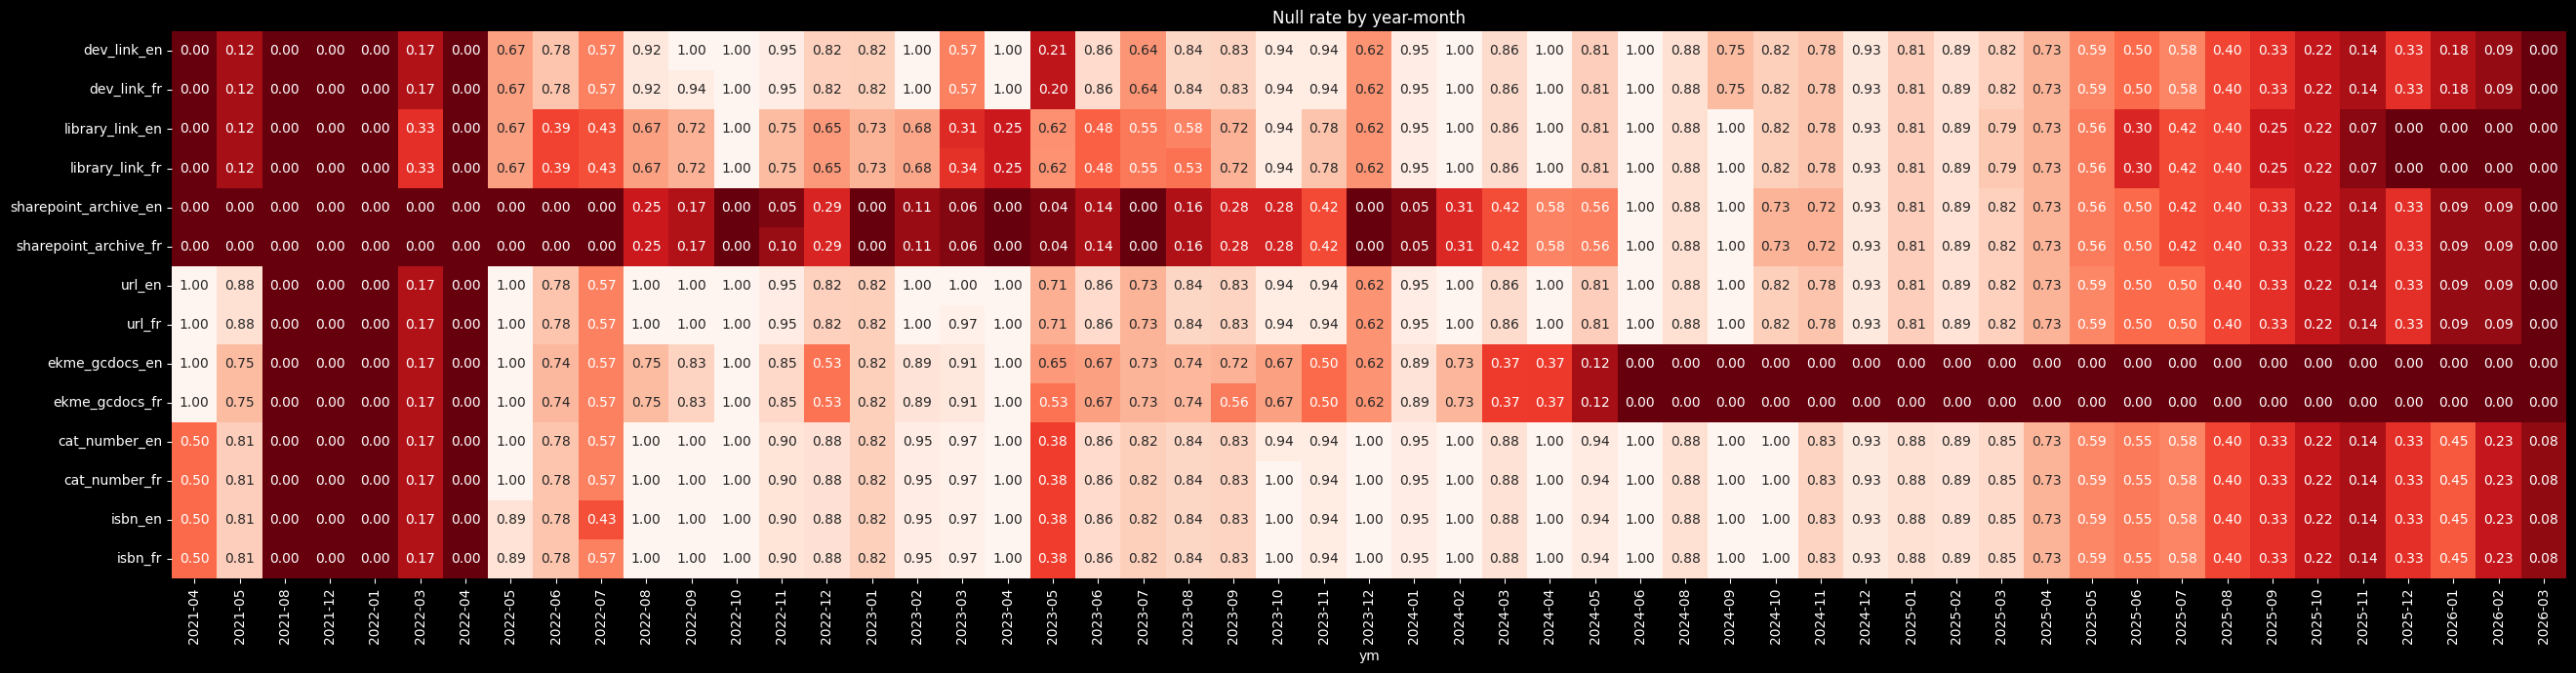

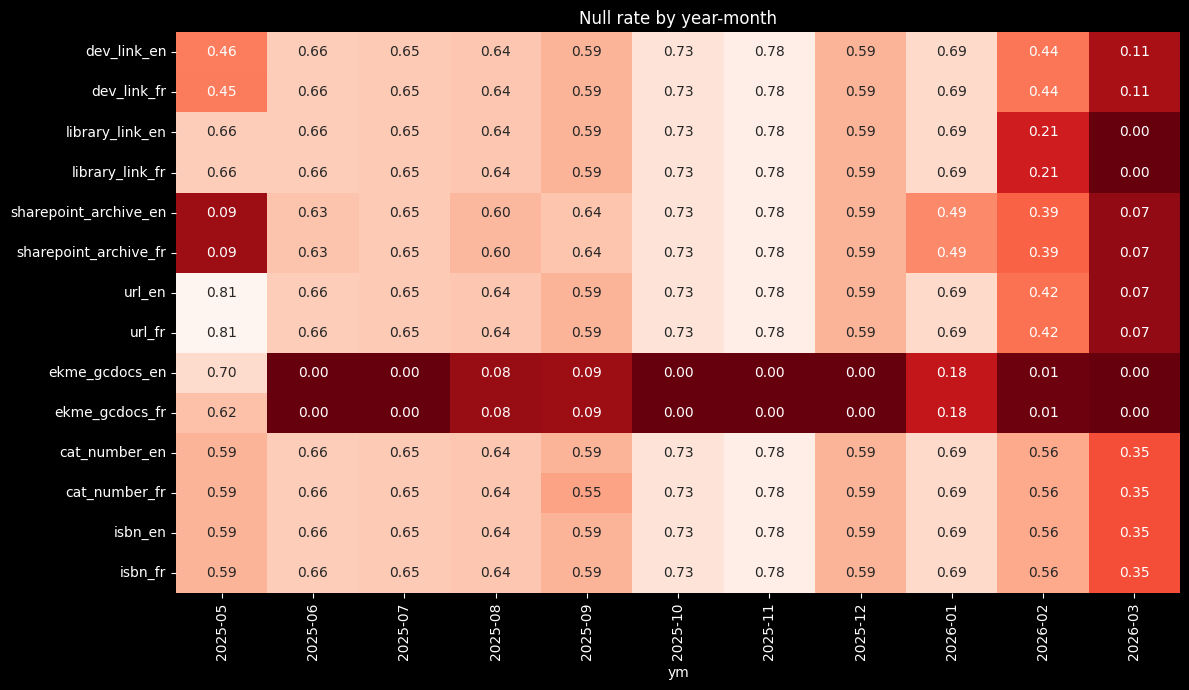

In [44]:
cmap = mlp.cm.Reds.reversed()

bool_cols = documents.columns[3:]
pivot = documents.assign(year=documents["created_at"].dt.year).groupby("year")[
    bool_cols].mean().astype(float)

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(len(bool_cols) * 0.8, 6))
    sns.heatmap(pivot.T, annot=True, fmt=".2f", cmap=cmap, ax=ax, cbar=False)
    ax.set_title("Null rate by year")
    plt.tight_layout()

bool_cols = documents.columns[3:]
pivot = \
documents.assign(ym=documents["created_at"].dt.to_period("M")).groupby("ym")[
    bool_cols].mean().astype(float)

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(
        figsize=(max(len(pivot) * 0.5, 12), len(bool_cols) * 0.5))
    sns.heatmap(pivot.T, annot=True, fmt=".2f", cmap=cmap, ax=ax, cbar=False)
    ax.set_title("Null rate by year-month")
    plt.xticks(rotation=90)
    plt.tight_layout()

# REDO for updated at vs created at

bool_cols = documents.columns[3:]
pivot = \
documents.assign(ym=documents["updated_at"].dt.to_period("M")).groupby("ym")[
    bool_cols].mean().astype(float)

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(
        figsize=(max(len(pivot) * 0.5, 12), len(bool_cols) * 0.5))
    sns.heatmap(pivot.T, annot=True, fmt=".2f", cmap=cmap, ax=ax, cbar=False)
    ax.set_title("Null rate by year-month")
    plt.xticks(rotation=90)
    plt.tight_layout()

### Notes:

- nothing surprising
    - ekme stopped being used
    - sharepoint started being used
    - latest documents are less likely to have links
    - all links used about equally
- potential updates:
    - deprecate the ekme fields?
    - no changes to other fields